In [6]:
from google.colab import files
uploaded = files.upload()

Saving Unemployment in India.csv to Unemployment in India (1).csv
Saving Unemployment_Rate_upto_11_2020.csv to Unemployment_Rate_upto_11_2020 (1).csv


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [9]:
# Replace filenames if needed
file1 = 'Unemployment in India (1).csv'
file2 = 'Unemployment_Rate_upto_11_2020 (1).csv'

# Load datasets
df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)

print(df1.head())
print(df2.head())

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  
           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0 

In [11]:
# Remove extra spaces from column names
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

print(df1.columns)
print(df2.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')
Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')


In [12]:
# Add missing columns if not present
if 'Area' not in df1.columns:
    df1['Area'] = 'Unknown'

if 'longitude' not in df2.columns:
    df2['longitude'] = 0

if 'latitude' not in df2.columns:
    df2['latitude'] = 0

if 'Region.1' not in df2.columns:
    df2['Region.1'] = 'Unknown'

In [13]:
combined_df = pd.concat([df1, df2], ignore_index=True)

print('Combined Dataset Shape:', combined_df.shape)
combined_df.head()

Combined Dataset Shape: (1035, 10)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Region.1,longitude,latitude
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural,NaN,NaN,NaN
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural,NaN,NaN,NaN
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural,NaN,NaN,NaN
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural,NaN,NaN,NaN
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural,NaN,NaN,NaN


In [14]:
combined_df = combined_df.fillna(method='ffill')
combined_df = combined_df.fillna(method='bfill')

/tmp/ipykernel_3295/1765247319.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  combined_df = combined_df.fillna(method='ffill')
/tmp/ipykernel_3295/1765247319.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  combined_df = combined_df.fillna(method='bfill')


In [15]:
combined_df['Date'] = pd.to_datetime(combined_df['Date'], errors='coerce')

combined_df['Year'] = combined_df['Date'].dt.year
combined_df['Month'] = combined_df['Date'].dt.month

/tmp/ipykernel_3295/2389780176.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  combined_df['Date'] = pd.to_datetime(combined_df['Date'], errors='coerce')


In [16]:
label_encoder = LabelEncoder()

categorical_cols = ['Region', 'Frequency', 'Area', 'Region.1']

for col in categorical_cols:
    combined_df[col] = label_encoder.fit_transform(combined_df[col].astype(str))

In [17]:
X = combined_df[[
    'Region',
    'Frequency',
    'Estimated Employed',
    'Estimated Labour Participation Rate (%)',
    'longitude',
    'latitude',
    'Area',
    'Region.1',
    'Year',
    'Month'
]]

# Target column
y = combined_df['Estimated Unemployment Rate (%)']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [20]:
y_pred = model.predict(X_test)

In [21]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('R2 Score:', r2)

Mean Absolute Error: 3.529837922705316
Mean Squared Error: 29.007875356243957
R2 Score: 0.7632404549097577


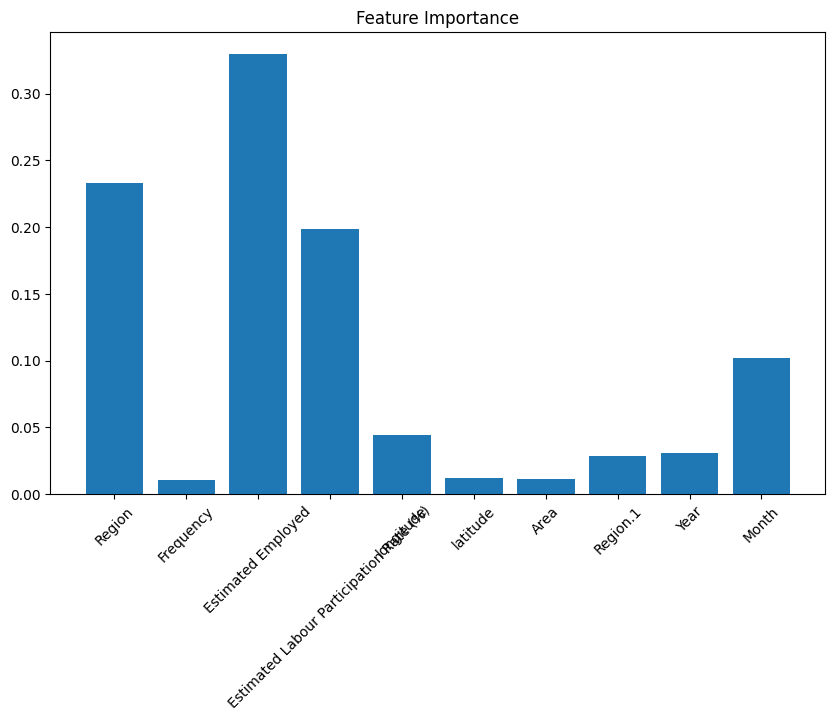

In [22]:
importance = model.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
plt.bar(features, importance)
plt.xticks(rotation=45)
plt.title('Feature Importance')
plt.show()

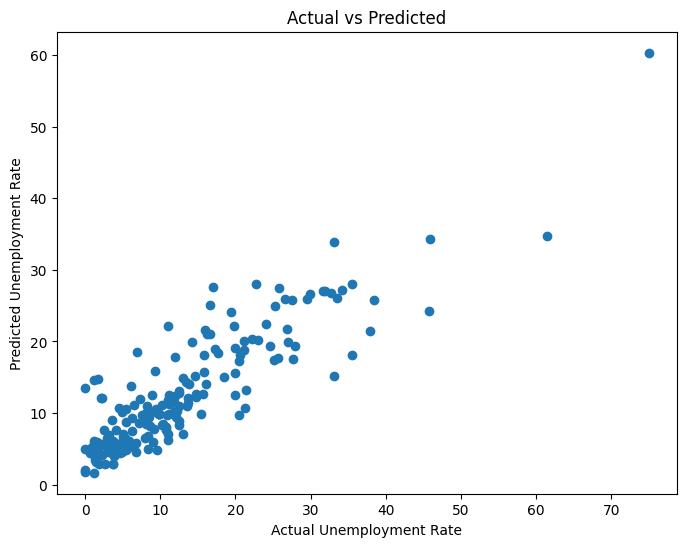

In [23]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Unemployment Rate')
plt.ylabel('Predicted Unemployment Rate')
plt.title('Actual vs Predicted')
plt.show()

In [24]:
import joblib

joblib.dump(model, 'unemployment_prediction_model.pkl')
print('Model Saved Successfully')


Model Saved Successfully
